In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
import random
import tensorflow as tf

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load Dataset

In [ ]:
pose_vector = pd.read_csv("output/pose.csv")
y = pose_vector.pop('Pose_Class').to_numpy()
y = [int(val.replace('P', '')) - 1 for val in y]
print(y)
points = pose_vector.to_numpy()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Reshape to body parts (instead of individual coordinates)

In [4]:
pose_vector = points.reshape((-1, 33, 4))
pose_vector.shape

(4467, 33, 4)

### List of joint connections

In [5]:
mp_pose = mp.solutions.pose
connections = mp_pose.POSE_CONNECTIONS
print(list(connections))

connections_array = np.array(list(connections)).T
print(connections_array)
print(connections_array.shape)

HAND_LANDMARKS = [15, 16, 17, 18, 19, 20, 21, 22]  # left_wrist to right_thumb_2

[(15, 21), (16, 20), (18, 20), (3, 7), (14, 16), (23, 25), (28, 30), (11, 23), (27, 31), (6, 8), (15, 17), (24, 26), (16, 22), (4, 5), (5, 6), (29, 31), (12, 24), (23, 24), (0, 1), (9, 10), (1, 2), (0, 4), (11, 13), (30, 32), (28, 32), (15, 19), (16, 18), (25, 27), (26, 28), (12, 14), (17, 19), (2, 3), (11, 12), (27, 29), (13, 15)]
[[15 16 18  3 14 23 28 11 27  6 15 24 16  4  5 29 12 23  0  9  1  0 11 30
  28 15 16 25 26 12 17  2 11 27 13]
 [21 20 20  7 16 25 30 23 31  8 17 26 22  5  6 31 24 24  1 10  2  4 13 32
  32 19 18 27 28 14 19  3 12 29 15]]
(2, 35)


### Visualise Skeleton

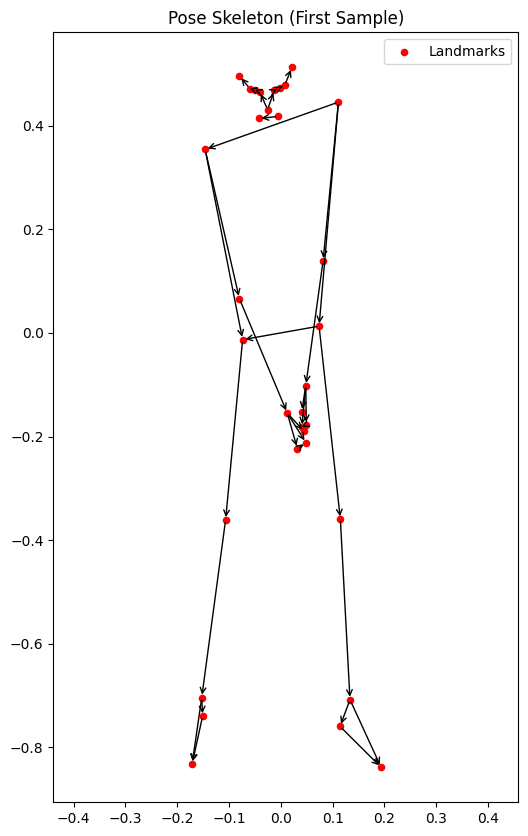

In [6]:
from matplotlib.patches import FancyArrowPatch

sample = pose_vector[0]

plt.figure(figsize=(6, 10))
plt.scatter(sample[:, 0], -sample[:, 1], c='red', s=20, label='Landmarks')

ax = plt.gca()
for start, end in connections:
    x_start, y_start = sample[start, 0], -sample[start, 1]
    x_end, y_end = sample[end, 0], -sample[end, 1]
    arrow = FancyArrowPatch((x_start, y_start), (x_end, y_end),
                            arrowstyle='->', color='k', mutation_scale=10, linewidth=1)
    ax.add_patch(arrow)

plt.title("Pose Skeleton (First Sample)")
plt.axis('equal')
plt.legend()
plt.show()

In [6]:
# Debug: Check coordinate ranges
sample_pose = pose_vector[0]
print(f"X range: {sample_pose[:, 0].min():.3f} to {sample_pose[:, 0].max():.3f}")
print(f"Y range: {sample_pose[:, 1].min():.3f} to {sample_pose[:, 1].max():.3f}")
print(f"Negated Y range: {(-sample_pose[:, 1]).min():.3f} to {(-sample_pose[:, 1]).max():.3f}")

X range: -0.171 to 0.193
Y range: -0.513 to 0.838
Negated Y range: -0.838 to 0.513


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch


def plot_pose_batches(pose_vector, y_labels, connections, batch_size=100, grid_cols=10):
    """
    Group poses by class and display batches of consecutive poses
    """
    # Group poses by their labels
    pose_groups = {}
    for i, label in enumerate(y_labels):
        pose_class = f'P{label+1}'
        if pose_class not in pose_groups:
            pose_groups[pose_class] = []
        pose_groups[pose_class].append((i, pose_vector[i]))
    
    # Create batches for each pose class
    for pose_class, poses_with_indices in pose_groups.items():
        print(f"\nProcessing {pose_class}: {len(poses_with_indices)} total poses")
        
        # Create batches of consecutive poses
        for batch_start in range(0, len(poses_with_indices), batch_size):
            batch_end = min(batch_start + batch_size, len(poses_with_indices))
            batch_poses = poses_with_indices[batch_start:batch_end]
            
            print(f"Creating batch {batch_start//batch_size + 1}: poses {batch_start+1}-{batch_end}")
            
            n_poses = len(batch_poses)
            grid_rows = (n_poses + grid_cols - 1) // grid_cols
            
            fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 2*grid_rows))
            if n_poses == 1:
                axes = [axes]
            else:
                axes = axes.flatten()
            
            for i, (original_idx, pose) in enumerate(batch_poses):
                ax = axes[i]
                
                # Plot connections
                for start, end in connections:
                    x_start, y_start = pose[start, 0], -pose[start, 1]
                    x_end, y_end = pose[end, 0], -pose[end, 1]
                    ax.plot([x_start, x_end], [y_start, y_end], 'k-', linewidth=0.8, alpha=0.7)
                
                # Plot landmarks
                for j in range(pose.shape[0]):
                    x, y = pose[j, 0], -pose[j, 1]
                    if j in HAND_LANDMARKS:
                        ax.scatter(x, y, c='blue', s=5, alpha=0.8)
                    else:
                        ax.scatter(x, y, c='red', s=5, alpha=0.8)         
                               
                ax.set_title(f'{original_idx}', fontsize=8)
                ax.set_aspect('equal')
                
                # Calculate limits for this specific pose with padding
                x_min, x_max = pose[:, 0].min(), pose[:, 0].max()
                y_min, y_max = (-pose[:, 1]).min(), (-pose[:, 1]).max()  # Using negated Y
                
                # Add padding (10% of the range, minimum 0.05)
                x_padding = max(0.05, (x_max - x_min) * 0.1)
                y_padding = max(0.05, (y_max - y_min) * 0.1)
                
                ax.set_xlim(x_min - x_padding, x_max + x_padding)
                ax.set_ylim(y_min - y_padding, y_max + y_padding)
                ax.axis('off')
            
            # Hide unused subplots
            for i in range(n_poses, len(axes)):
                axes[i].axis('off')
            
            batch_num = batch_start//batch_size + 1
            total_batches = (len(poses_with_indices) + batch_size - 1) // batch_size
            plt.suptitle(f"{pose_class} - Batch {batch_num}/{total_batches} (Poses {batch_start+1}-{batch_end})", 
                        fontsize=16, y=0.98)
            plt.tight_layout()
            
            # Save the image instead of showing it
            filename = f"{pose_class}_batch_{batch_num}_of_{total_batches}.png"
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            plt.close()  # Close to free memory
            print(f"Saved: {filename}")

def plot_single_class_batches(pose_vector, y_labels, connections, target_class, batch_size=100, grid_cols=10):
    """
    Display batches for a specific pose class only
    """
    # Filter poses for the target class
    target_label = target_class - 1  # Convert P1-P10 to 0-9
    class_poses = [(i, pose_vector[i]) for i, label in enumerate(y_labels) if label == target_label]
    
    if not class_poses:
        print(f"No poses found for P{target_class}")
        return
    
    print(f"Found {len(class_poses)} poses for P{target_class}")
    
    # Create batches
    for batch_start in range(0, len(class_poses), batch_size):
        batch_end = min(batch_start + batch_size, len(class_poses))
        batch_poses = class_poses[batch_start:batch_end]
        
        n_poses = len(batch_poses)
        grid_rows = (n_poses + grid_cols - 1) // grid_cols
        
        fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 2*grid_rows))
        if n_poses == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, (original_idx, pose) in enumerate(batch_poses):
            ax = axes[i]
            
            # Plot connections
            for start, end in connections:
                x_start, y_start = pose[start, 0], -pose[start, 1]
                x_end, y_end = pose[end, 0], -pose[end, 1]
                ax.plot([x_start, x_end], [y_start, y_end], 'k-', linewidth=0.8, alpha=0.7)
            
            # Plot landmarks
            ax.scatter(pose[:, 0], -pose[:, 1], c='red', s=5, alpha=0.8)
            
            ax.set_title(f'{original_idx}', fontsize=8)
            ax.set_aspect('equal')
            
            # Calculate limits for this specific pose with padding
            x_min, x_max = pose[:, 0].min(), pose[:, 0].max()
            y_min, y_max = (-pose[:, 1]).min(), (-pose[:, 1]).max()  # Using negated Y
            
            # Add padding (10% of the range, minimum 0.05)
            x_padding = max(0.05, (x_max - x_min) * 0.1)
            y_padding = max(0.05, (y_max - y_min) * 0.1)
            
            ax.set_xlim(x_min - x_padding, x_max + x_padding)
            ax.set_ylim(y_min - y_padding, y_max + y_padding)
            ax.axis('off')
        
        # Hide unused subplots
        for i in range(n_poses, len(axes)):
            axes[i].axis('off')
        
        batch_num = batch_start//batch_size + 1
        total_batches = (len(class_poses) + batch_size - 1) // batch_size
        plt.suptitle(f"P{target_class} - Batch {batch_num}/{total_batches} (Poses {batch_start+1}-{batch_end})", 
                    fontsize=16, y=0.98)
        plt.tight_layout()
        
        # Save the image instead of showing it
        filename = f"P{target_class}_batch_{batch_num}_of_{total_batches}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()  # Close to free memory
        print(f"Saved: {filename}")

def get_class_statistics(y_labels):
    """
    Display statistics about pose classes
    """
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    print("Pose Class Statistics:")
    print("-" * 30)
    for label, count in zip(unique_labels, counts):
        print(f"P{label+1}: {count} poses")
    print(f"\nTotal poses: {len(y_labels)}")

# Usage examples:

# First, check the distribution of your data
get_class_statistics(y)

# Display batches for ALL pose classes
plot_pose_batches(pose_vector, y, connections, batch_size=100, grid_cols=10)

# Display batches for a SPECIFIC pose class only
# For example, to see all P1 poses in batches of 100:
# plot_single_class_batches(pose_vector, y, connections, target_class=1, batch_size=100, grid_cols=10)

Pose Class Statistics:
------------------------------
P1: 484 poses
P2: 438 poses
P3: 461 poses
P4: 460 poses
P5: 392 poses
P6: 332 poses
P7: 402 poses
P8: 455 poses
P9: 414 poses
P10: 629 poses

Total poses: 4467

Processing P1: 484 total poses
Creating batch 1: poses 1-100
Saved: P1_batch_1_of_5.png
Creating batch 2: poses 101-200
Saved: P1_batch_2_of_5.png
Creating batch 3: poses 201-300
Saved: P1_batch_3_of_5.png
Creating batch 4: poses 301-400
Saved: P1_batch_4_of_5.png
Creating batch 5: poses 401-484
Saved: P1_batch_5_of_5.png

Processing P10: 629 total poses
Creating batch 1: poses 1-100
Saved: P10_batch_1_of_7.png
Creating batch 2: poses 101-200
Saved: P10_batch_2_of_7.png
Creating batch 3: poses 201-300
Saved: P10_batch_3_of_7.png
Creating batch 4: poses 301-400
Saved: P10_batch_4_of_7.png
Creating batch 5: poses 401-500
Saved: P10_batch_5_of_7.png
Creating batch 6: poses 501-600
Saved: P10_batch_6_of_7.png
Creating batch 7: poses 601-629
Saved: P10_batch_7_of_7.png

Processin

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

def denormalize_landmarks(normalized_landmarks, original_image_path, torso_size_multiplier=2.5):
    """
    Convert normalized landmarks back to original image coordinates
    """
    # Load original image to get dimensions
    image = cv2.imread("./Dataset/" + original_image_path)
    if image is None:
        raise ValueError(f"Could not load image: ./Dataset/{original_image_path}")
    
    h, w, c = image.shape
    
    # Process image with MediaPipe to get original landmarks for reference
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose()
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_rgb = np.ascontiguousarray(img_rgb, dtype=np.uint8)
    result = pose.process(img_rgb)
    
    if not result.pose_landmarks:
        raise ValueError("No pose landmarks detected in original image")
    
    # Get original landmarks to calculate the normalization parameters
    landmark_names = [
        'nose', 'left_eye_inner', 'left_eye', 'left_eye_outer',
        'right_eye_inner', 'right_eye', 'right_eye_outer',
        'left_ear', 'right_ear', 'mouth_left', 'mouth_right',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_pinky_1', 'right_pinky_1',
        'left_index_1', 'right_index_1', 'left_thumb_2', 'right_thumb_2',
        'left_hip', 'right_hip', 'left_knee', 'right_knee',
        'left_ankle', 'right_ankle', 'left_heel', 'right_heel',
        'left_foot_index', 'right_foot_index'
    ]
    
    # Extract original landmarks
    lm_list = []
    for landmarks in result.pose_landmarks.landmark:
        lm_list.append(landmarks)
    
    # Calculate original normalization parameters
    center_x = (lm_list[landmark_names.index('right_hip')].x +
                lm_list[landmark_names.index('left_hip')].x) * 0.5
    center_y = (lm_list[landmark_names.index('right_hip')].y +
                lm_list[landmark_names.index('left_hip')].y) * 0.5
    
    shoulders_x = (lm_list[landmark_names.index('right_shoulder')].x +
                   lm_list[landmark_names.index('left_shoulder')].x) * 0.5
    shoulders_y = (lm_list[landmark_names.index('right_shoulder')].y +
                   lm_list[landmark_names.index('left_shoulder')].y) * 0.5
    
    # Calculate max_distance used in normalization
    max_distance = 0
    for lm in lm_list:
        distance = np.sqrt((lm.x - center_x)**2 + (lm.y - center_y)**2)
        if distance > max_distance:
            max_distance = distance
    
    torso_size = np.sqrt((shoulders_x - center_x)**2 + (shoulders_y - center_y)**2)
    max_distance = max(torso_size * torso_size_multiplier, max_distance)
    
    # Convert normalized landmarks back to original coordinates
    denormalized_landmarks = []
    for i in range(0, len(normalized_landmarks), 4):  # x, y, z, v for each landmark
        norm_x = normalized_landmarks[i]
        norm_y = normalized_landmarks[i + 1]
        norm_z = normalized_landmarks[i + 2]
        visibility = normalized_landmarks[i + 3]
        
        # Reverse the normalization
        original_x = (norm_x * max_distance + center_x) * w
        original_y = (norm_y * max_distance + center_y) * h
        original_z = norm_z * max_distance
        
        denormalized_landmarks.extend([original_x, original_y, original_z, visibility])
    
    return denormalized_landmarks, (w, h)

def plot_pose_overlay_batches(image_paths, normalized_landmarks_list, y_labels, target_class=None,
                               batch_size=100, grid_cols=10, output_dir="pose_overlay_batches"):
    """
    Overlay denormalized pose landmarks on original images and save them in batch grids.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Filter if target_class is provided (1-based: P1, P2, ...)
    filtered = []
    for idx, (img_path, landmarks, label) in enumerate(zip(image_paths, normalized_landmarks_list, y_labels)):
        if (target_class is None) or (label == target_class - 1):
            filtered.append((idx, img_path, landmarks, label))

    if not filtered:
        print(f"No poses found for class: P{target_class}" if target_class else "No poses found.")
        return

    print(f"[INFO] Found {len(filtered)} poses for {'P'+str(target_class) if target_class else 'all classes'}")

    for batch_start in range(0, len(filtered), batch_size):
        batch_end = min(batch_start + batch_size, len(filtered))
        batch = filtered[batch_start:batch_end]
        n_poses = len(batch)
        grid_rows = (n_poses + grid_cols - 1) // grid_cols

        fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 3, grid_rows * 3))
        axes = axes.flatten() if n_poses > 1 else [axes]

        for i, (original_idx, img_path, norm_lm, label) in enumerate(batch):
            ax = axes[i]
            try:
                # Load image
                image = cv2.imread("./Dataset/" + img_path)
                if image is None:
                    print(f"[WARN] Could not load image: {img_path}")
                    continue
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Denormalize landmarks
                denorm_landmarks, _ = denormalize_landmarks(norm_lm, img_path)

                ax.imshow(image_rgb)

                # Plot landmarks with color coding
                for j in range(0, len(denorm_landmarks), 4):
                    idx = j // 4
                    x = denorm_landmarks[j]
                    y = denorm_landmarks[j + 1]
                    visibility = denorm_landmarks[j + 3]
                    if visibility > 0.5:
                        color = 'blue' if idx in HAND_LANDMARKS else 'red'
                        ax.scatter(x, y, c=color, s=10, alpha=0.8)

                # Plot connections
                for start, end in connections:
                    sx, sy, sv = denorm_landmarks[start * 4:start * 4 + 2] + [denorm_landmarks[start * 4 + 3]]
                    ex, ey, ev = denorm_landmarks[end * 4:end * 4 + 2] + [denorm_landmarks[end * 4 + 3]]
                    if sv > 0.5 and ev > 0.5:
                        ax.plot([sx, ex], [sy, ey], 'b-', linewidth=1, alpha=0.6)

                ax.set_title(f"P{label+1} #{original_idx}", fontsize=8)
                ax.axis('off')
            except Exception as e:
                print(f"[ERROR] Failed to process image {img_path}: {e}")
                ax.axis('off')

        # Hide unused axes
        for i in range(n_poses, len(axes)):
            axes[i].axis('off')

        # Save
        batch_num = batch_start // batch_size + 1
        total_batches = (len(filtered) + batch_size - 1) // batch_size
        title = f"P{target_class}" if target_class else "All Poses"
        filename = os.path.join(output_dir, f"{title}_batch_{batch_num}_of_{total_batches}.png")

        plt.suptitle(f"{title} - Batch {batch_num}/{total_batches}", fontsize=16)
        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"[SAVED] {filename}")

df = pd.read_csv("pose_img.csv")
image_paths = df["Image_Path"].tolist()
pose_vectors = df.drop(["Pose_Class", "Image_Path"], axis=1).values
y_labels = df["Pose_Class"].apply(lambda x: int(x[1:]) - 1).values  # Convert P1 → 0

# Call for specific class
for i in range(9, 10):
    plot_pose_overlay_batches(image_paths, pose_vectors, y_labels, target_class=i+1)

# Or for all classes
# plot_pose_overlay_batches(image_paths, pose_vectors, y_labels)

[INFO] Found 629 poses for P10
[SAVED] pose_overlay_batches\P10_batch_1_of_7.png
[SAVED] pose_overlay_batches\P10_batch_2_of_7.png
[SAVED] pose_overlay_batches\P10_batch_3_of_7.png
[SAVED] pose_overlay_batches\P10_batch_4_of_7.png
[SAVED] pose_overlay_batches\P10_batch_5_of_7.png
[ERROR] Failed to process image P10/trimmed_276Ec8-zeW8_mp4-30_jpg.rf.de5d963d1b8b72b4cb3f493495655f50.jpg: No pose landmarks detected in original image
[ERROR] Failed to process image P10/trimmed_9vZrL5oMCrc_mp4-27_jpg.rf.7bda396dd2ff94a0f5f141131bfe2c85.jpg: No pose landmarks detected in original image
[SAVED] pose_overlay_batches\P10_batch_6_of_7.png
[SAVED] pose_overlay_batches\P10_batch_7_of_7.png
